In [5]:
# Import Library & Persiapan Citra

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load citra
citra_A_path = '20260130_104702.jpg.jpeg' # Citra asli (tanpa mobil)
citra_B_path = 'Gemini_Generated_Image_wperl5wperl5wper.png' # Citra manipulasi (ada mobil putih)

citra_A = cv2.imread(citra_A_path, cv2.IMREAD_GRAYSCALE)
citra_B = cv2.imread(citra_B_path, cv2.IMREAD_GRAYSCALE)

# 2. Pengecekan jika gambar gagal dimuat
if citra_A is None or citra_B is None:
    print("Error: Gambar tidak ditemukan. Pastikan sudah di-upload ke session storage Colab.")
else:
    # 3. Resize gambar agar ukuran M x N sama persis
    # (Dan diperkecil sedikit agar proses Looping Python tidak makan waktu bermenit-menit)
    target_dim = (600, 800) # Lebar x Tinggi
    citra_A = cv2.resize(citra_A, target_dim)
    citra_B = cv2.resize(citra_B, target_dim)

    # Ambil dimensi M (baris/tinggi) dan N (kolom/lebar)
    M, N = citra_A.shape
    print(f"Dimensi citra yang diproses: {M} baris x {N} kolom")

Dimensi citra yang diproses: 800 baris x 600 kolom


In [8]:
# Fungsi Pengurangan Citra

def substraction_toleransi(A, B, M, N, threshold=40):
    """
    Fungsi pengurangan citra dengan batas toleransi noise.
    """
    C = np.zeros((M, N), dtype=np.uint8)

    for i in range(M):
        for j in range(N):
            # Hitung selisih
            selisih = int(A[i, j]) - int(B[i, j])

            # CEK TOLERANSI: Jika selisihnya lebih besar dari 40 (bukan sekadar != 0)
            # abs() digunakan untuk mengubah nilai negatif jadi positif (misal -50 jadi 50)
            if abs(selisih) > threshold:
                C[i, j] = 255  # Ini perubahan besar (Mobil) -> Putih
            else:
                C[i, j] = 0    # Ini cuma noise/background -> Hitam

    return C

# Eksekusi fungsi dengan batas toleransi 40
print("Sedang memproses pengurangan citra (dengan toleransi)...")
citra_C = substraction_toleransi(citra_A, citra_B, M, N, threshold=40)
print("Proses selesai!")

Sedang memproses pengurangan citra (dengan toleransi)...
Proses selesai!


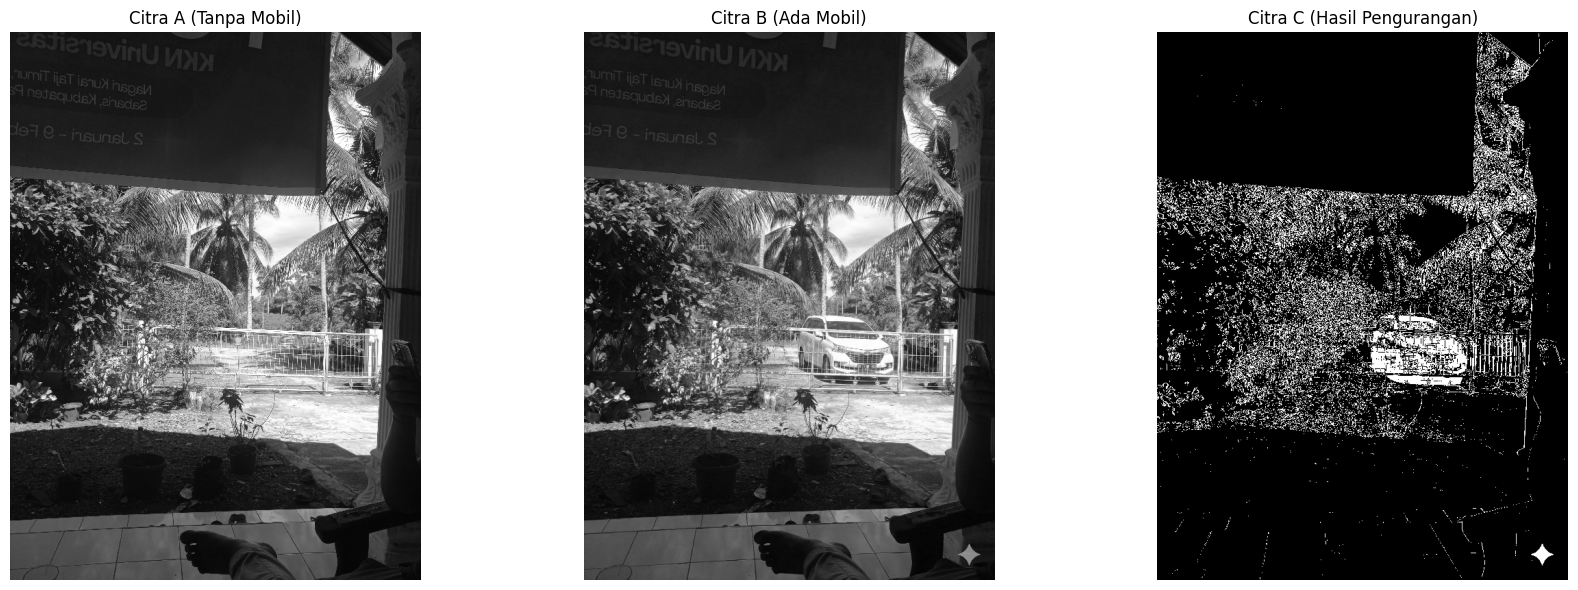

In [9]:
# Visualisasi Hasil

plt.figure(figsize=(18, 6))

# Plot Citra A
plt.subplot(1, 3, 1)
plt.imshow(citra_A, cmap='gray')
plt.title('Citra A (Tanpa Mobil)')
plt.axis('off')

# Plot Citra B
plt.subplot(1, 3, 2)
plt.imshow(citra_B, cmap='gray')
plt.title('Citra B (Ada Mobil)')
plt.axis('off')

# Plot Citra C (Hasil)
plt.subplot(1, 3, 3)
plt.imshow(citra_C, cmap='gray')
plt.title('Citra C (Hasil Pengurangan)')
plt.axis('off')

plt.tight_layout()
plt.show()